In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

C:\Users\Hidou\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = r"C:\Users\Hidou\Documents\4DS1\SEM2\PI\DATA COLLECTED FOR PI\BRANDS\Final\service_providers.csv"
df = pd.read_csv(file_path)

print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nSummary Statistics (Numerical):")
display(df.describe())

print("\nSummary Statistics (Categorical):")
display(df.describe(include=['object']))


First 5 rows of the dataset:


,provider_id,company_name,service_type,region,contact_email,phone_number,partnerships_made,website
0,1,KINEXON Sports,Technology & Analytics,International,info@kinexon-sports.com,+49 89 200 61 65 0,"European Handball Federation, Unrivaled Women'...",https://kinexon-sports.com/
1,2,Relevent Sports,Event Organizers,International,info@releventsports.com,+1 212-920-7950,"International Champions Cup, LaLiga North America",https://www.relevent.com/
2,3,Seamoriow Sports,Soccer Facilities,Nigeria,contact@seamoriowsports.com,+234 803 000 0000,Lagos State Football Associations,https://seamoriowsports.com/
3,4,Football for Hope Movement,Charity & Community Programs,Africa,info@footballforhope.org,+41 43 222 7777,FIFA,https://www.fifa.com/social-impact/football-fo...
4,5,Sportian,Technology & Analytics,International,info@sportian.com,+34 91 123 4567,"LaLiga, Microsoft",https://www.sportian.com/



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   provider_id        404 non-null    int64 
 1   company_name       404 non-null    object
 2   service_type       404 non-null    object
 3   region             404 non-null    object
 4   contact_email      404 non-null    object
 5   phone_number       401 non-null    object
 6   partnerships_made  404 non-null    object
 7   website            404 non-null    object
dtypes: int64(1), object(7)
memory usage: 25.4+ KB

Summary Statistics (Numerical):


,provider_id
count,404.000000
mean,203.467822
std,116.823132
min,1.000000
25%,102.750000
50%,203.500000
75%,304.250000
max,405.000000



Summary Statistics (Categorical):


,company_name,service_type,region,contact_email,phone_number,partnerships_made,website
count,404,404,404,404,401,404,404
unique,384,6,17,378,106,294,377
top,Kickstart Football Foundation,Technology & Analytics,International,info@prosoccerwellness.com,+44 203 555 5432,"A-League clubs, FIFA medical programs",https://www.prosoccerwellness.com/
freq,3,128,166,3,30,8,3



Missing Values:


provider_id          0
company_name         0
service_type         0
region               0
contact_email        0
phone_number         3
partnerships_made    0
website              0
dtype: int64

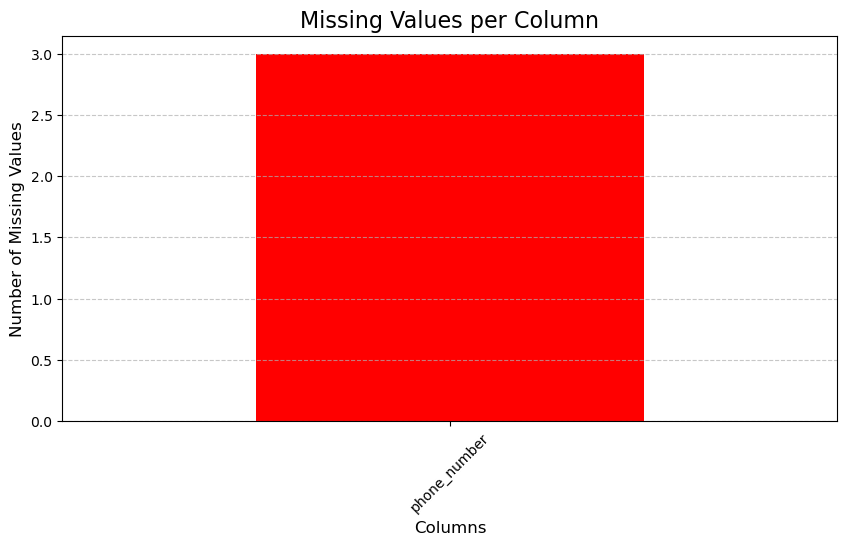

In [3]:
missing_values = df.isnull().sum()
print("\nMissing Values:")
display(missing_values)

if missing_values.sum() > 0:
    plt.figure(figsize=(10, 5))
    missing_values[missing_values > 0].plot(kind='bar', color='red')
    plt.title('Missing Values per Column', fontsize=16)
    plt.xlabel('Columns', fontsize=12)
    plt.ylabel('Number of Missing Values', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # Fill missing phone numbers with a placeholder
    df['phone_number'].fillna('Unknown', inplace=True)
else:
    print("No missing values found.")

In [4]:
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = df[col].astype('category')
print("\nData Types after Conversion:")
display(df.dtypes)


Data Types after Conversion:


provider_id             int64
company_name         category
service_type         category
region               category
contact_email        category
phone_number         category
partnerships_made    category
website              category
dtype: object

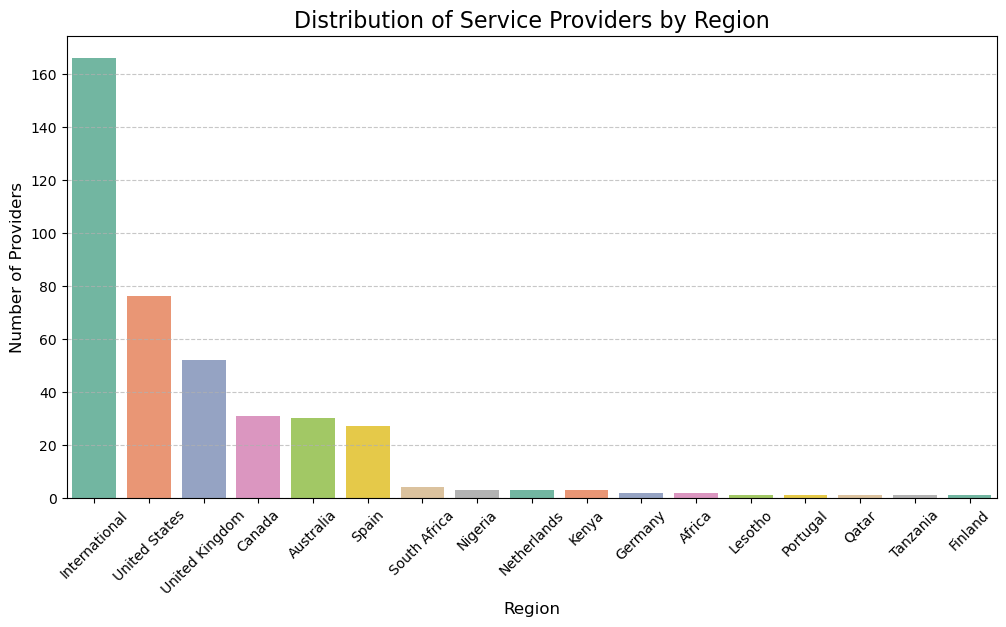

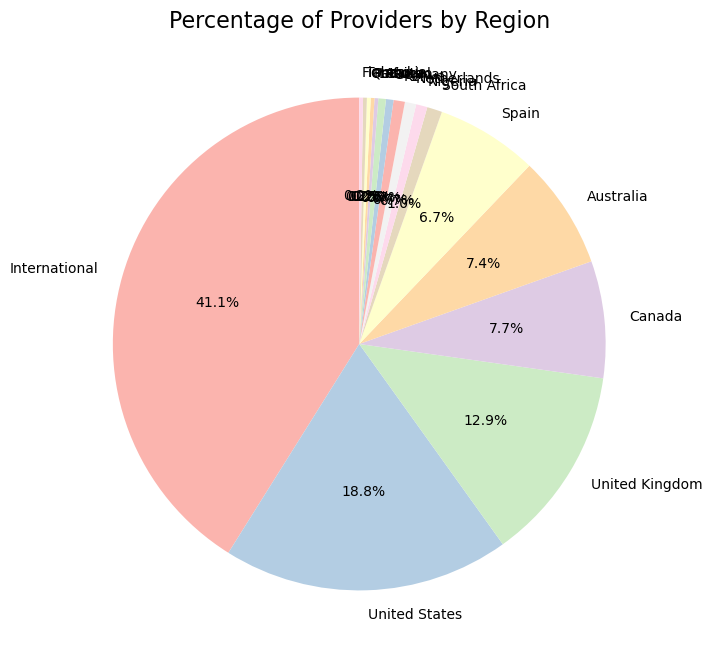

In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='region', palette='Set2', order=df['region'].value_counts().index)
plt.title('Distribution of Service Providers by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Providers', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Pie Chart for Region Distribution
plt.figure(figsize=(8, 8))
df['region'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Pastel1'), startangle=90)
plt.title('Percentage of Providers by Region', fontsize=16)
plt.ylabel('')
plt.show()

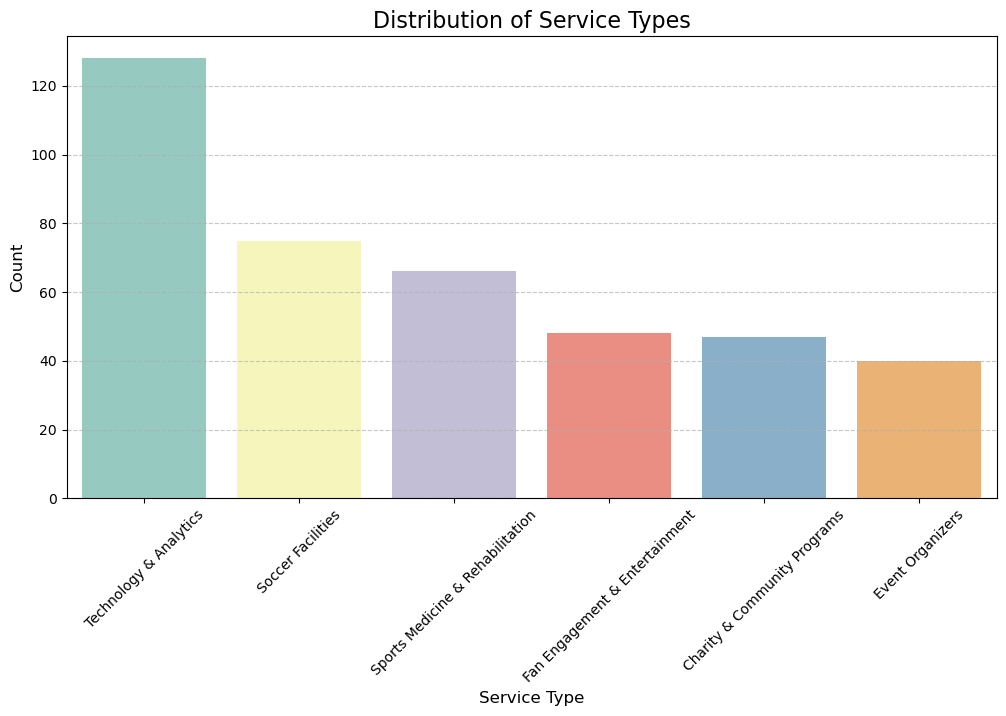

In [7]:
# Cell 6: Service Type Analysis
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='service_type', palette='Set3', order=df['service_type'].value_counts().index)
plt.title('Distribution of Service Types', fontsize=16)
plt.xlabel('Service Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

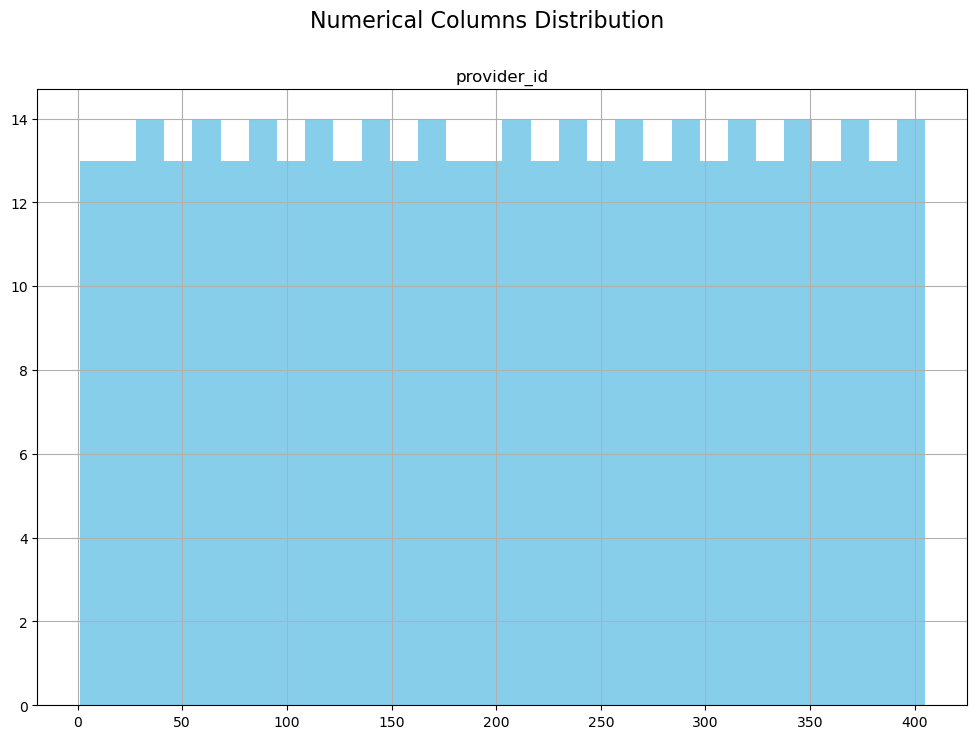

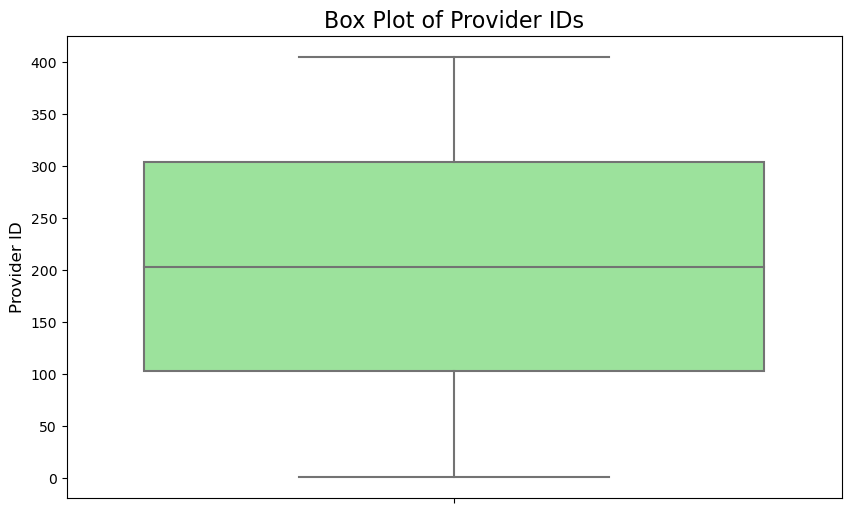

In [9]:
numerical_columns = df.select_dtypes(include=['number']).columns
if len(numerical_columns) > 0:
    df[numerical_columns].hist(figsize=(12, 8), bins=30, color='skyblue')
    plt.suptitle('Numerical Columns Distribution', fontsize=16)
    plt.show()
else:
    print("No numerical columns beyond 'provider_id' found.")

# Box Plot for provider_id (if meaningful)
plt.figure(figsize=(10, 6))
sns.boxplot(y='provider_id', data=df, color='lightgreen')
plt.title('Box Plot of Provider IDs', fontsize=16)
plt.ylabel('Provider ID', fontsize=12)
plt.show()

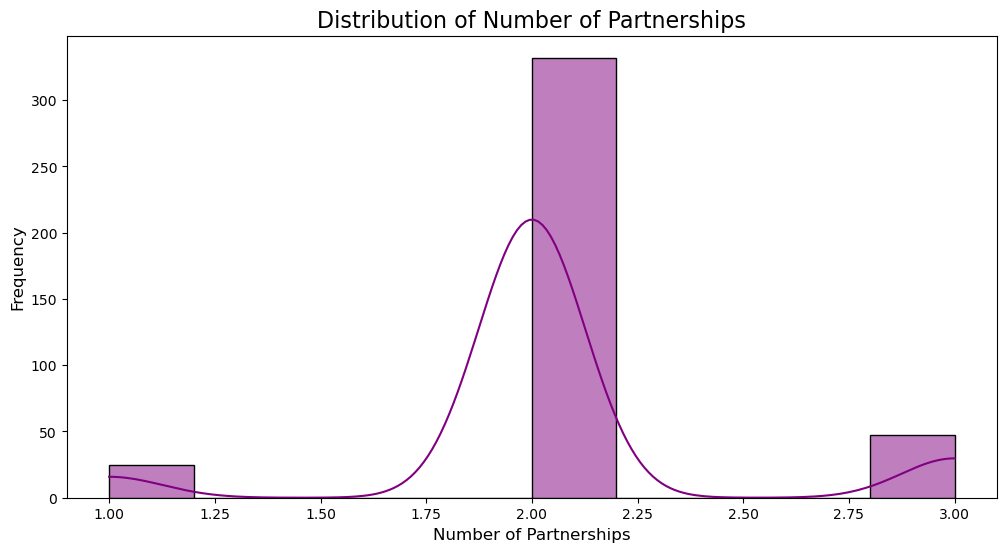

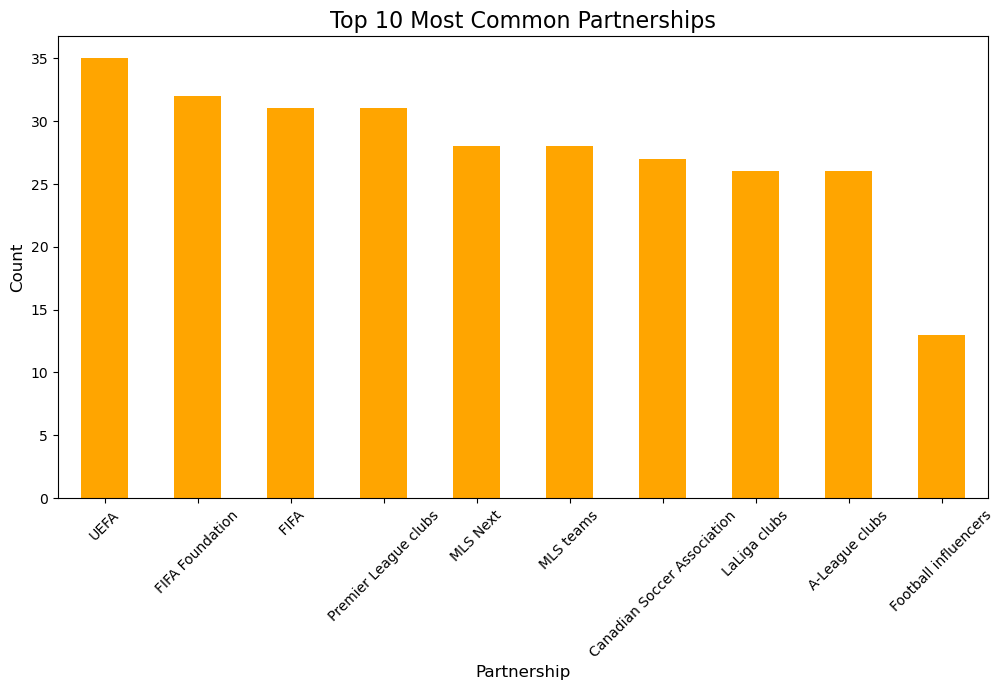

In [10]:
# Count number of partnerships per provider
df['partnership_count'] = df['partnerships_made'].apply(lambda x: len(str(x).split(',')))
plt.figure(figsize=(12, 6))
sns.histplot(df['partnership_count'], bins=10, kde=True, color='purple')
plt.title('Distribution of Number of Partnerships', fontsize=16)
plt.xlabel('Number of Partnerships', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Top Partnerships
top_partnerships = df['partnerships_made'].str.split(',', expand=True).stack().value_counts().head(10)
plt.figure(figsize=(12, 6))
top_partnerships.plot(kind='bar', color='orange')
plt.title('Top 10 Most Common Partnerships', fontsize=16)
plt.xlabel('Partnership', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [11]:
le = LabelEncoder()
df_encoded = df.copy()
for col in ['service_type', 'region']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Use partnership_count as a numerical feature
X = df_encoded[['service_type', 'region', 'partnership_count']]


Columns after PCA and Clustering:


['provider_id',
 'company_name',
 'service_type',
 'region',
 'contact_email',
 'phone_number',
 'partnerships_made',
 'website',
 'partnership_count',
 'cluster',
 'PCA1',
 'PCA2']

First few rows with PCA and cluster:


,PCA1,PCA2,cluster
0,3.318548,-2.195324,2
1,3.697606,1.782907,0
2,-0.485801,0.132257,0
3,8.757320,2.259133,0
4,3.318548,-2.195324,2


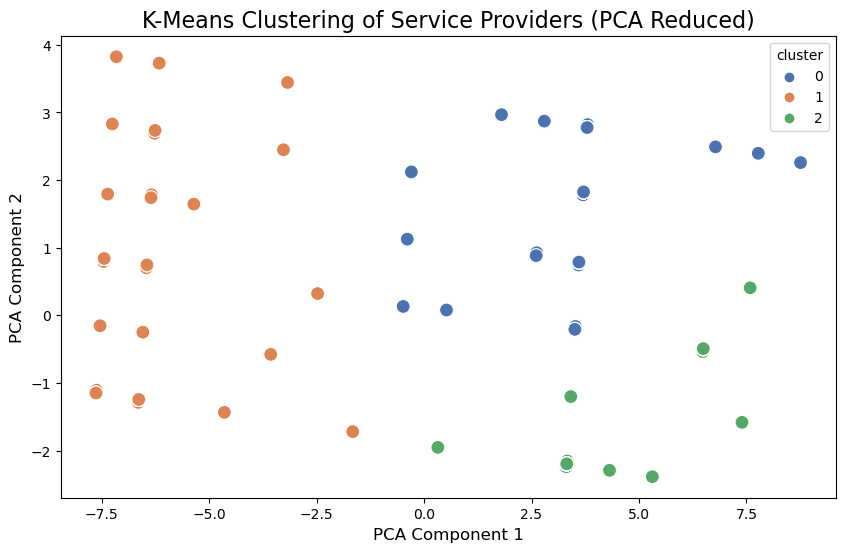

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# PCA for Visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

print("\nColumns after PCA and Clustering:")
display(df.columns.tolist())
print("First few rows with PCA and cluster:")
display(df[['PCA1', 'PCA2', 'cluster']].head())

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=df, palette='deep', s=100)
plt.title('K-Means Clustering of Service Providers (PCA Reduced)', fontsize=16)
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.show()

In [13]:
print("\nCluster Summary:")
cluster_summary = df.groupby('cluster').agg({
    'company_name': 'count',
    'service_type': lambda x: x.mode()[0],
    'region': lambda x: x.mode()[0],
    'partnership_count': 'mean'
}).rename(columns={'company_name': 'count'})
print(cluster_summary)


Cluster Summary:
         count                  service_type         region  partnership_count
cluster                                                                       
0          123  Charity & Community Programs  International           2.235772
1          162        Technology & Analytics  United States           1.950617
2          119        Technology & Analytics  International           2.008403


In [14]:
output_path = r"C:\Users\Hidou\Documents\4DS1\SEM2\PI\DATA COLLECTED FOR PI\BRANDS\Final\enhanced_service_providers.csv"
df.to_csv(output_path, index=False)
print(f"Enhanced data saved to: {output_path}")

Enhanced data saved to: C:\Users\Hidou\Documents\4DS1\SEM2\PI\DATA COLLECTED FOR PI\BRANDS\Final\enhanced_service_providers.csv
